In [149]:
# Add all necessary libraries

import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns


%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [150]:
# Load data Set
auction_df = pd.read_csv(r'C:\Users\Solen Tadesse\ALX_ML\PORTFOLIO\Compiled_csv_file\compiled.csv')
auction_df.head()

,No,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1.0,1,"93,460.00",40%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,NaN,2,"36,100.00",100%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,NaN,3,"56,545.00",61%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,2.0,1,"45,800.00",100%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,NaN,2,"51,999.00",52%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [151]:
# Are there null values in the dataset?
auction_df.isnull().sum()


No                      3007
Grade                      0
Price per m2               0
Advance payment in %       0
Sub-City                   0
Woreda                     0
Area size in m2            0
Area code                  0
                        3007
Date                       0
Remark                  4564
dtype: int64

In [152]:
#Drop the 'No' column
auction_df.drop(columns=['No'], inplace=True)


In [153]:
# see top 5 rows of the dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,"93,460.00",40%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,2,"36,100.00",100%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,3,"56,545.00",61%,Kolfe Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,1,"45,800.00",100%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,2,"51,999.00",52%,Kolfe Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [154]:
# for every unique element in the'Sub-City' column,replace spaces and hyphens with underscores
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace(' ', '_')
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace('-', '_')

In [155]:
#see top 5 rows of the dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,"93,460.00",40%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,Highest Bidder,04--2024,NaN
1,2,"36,100.00",100%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
2,3,"56,545.00",61%,Kolfe_Keraniyo,3,214,LDR_KOL_MIX_00013050,NaN,04--2024,NaN
3,1,"45,800.00",100%,Kolfe_Keraniyo,3,546,LDR_KOL_MIX_00013051,Highest Point,04--2024,NaN
4,2,"51,999.00",52%,Kolfe_Keraniyo,3,546,LDR_KOL_MIX_00013051,NaN,04--2024,NaN


In [156]:
# list all unique elements in 'Sub-City' column
auction_df['Sub-City'].unique()

array(['Kolfe_Keraniyo', 'Kirkos', 'Yeka', 'Gullele', 'Bole', 'Lideta',
       'Akaki_Kality', 'Arada', 'Addis_Ketema', 'Nifas_Silk_Lafto',
       'Nifas_Silk_Lafto\xa0', 'Gullele\xa0', 'Bole\xa0', 'Lemi_Kura'],
      dtype=object)

In [157]:
# use a regex pattern to remove non-breaking spaces (represented as \xa0) in the 'Sub-City' column
auction_df['Sub-City'] = auction_df['Sub-City'].str.replace(r'\xa0', '', regex=True)

In [158]:
## list all unique elements in 'Sub-City' column
auction_df['Sub-City'].unique()

array(['Kolfe_Keraniyo', 'Kirkos', 'Yeka', 'Gullele', 'Bole', 'Lideta',
       'Akaki_Kality', 'Arada', 'Addis_Ketema', 'Nifas_Silk_Lafto',
       'Lemi_Kura'], dtype=object)

In [159]:
# first replace '--' with '-'from the 'Date' column
auction_df['Date'] = auction_df['Date'].str.replace('--', '-')  
# convert the 'Date' column to datetime format                  
auction_df['Date'] = pd.to_datetime(auction_df['Date'], format='%m-%Y') 

In [160]:
# observe data types of each column
auction_df.dtypes

Grade                            int64
Price per m2                    object
Advance payment in %            object
Sub-City                        object
Woreda                           int64
Area size in m2                 object
Area code                       object
                                object
Date                    datetime64[ns]
Remark                          object
dtype: object

In [161]:
# clean all characters from 'Price per m2', 'Area size in m2', and 'Advance payment in %' columns and convert them to float 
auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']] = auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']].apply(lambda x: x.str.replace(r'[^\d\.]', '', regex=True))
auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']] = auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']].astype(float)        

In [162]:
# check the data types again
auction_df.dtypes

Grade                            int64
Price per m2                   float64
Advance payment in %           float64
Sub-City                        object
Woreda                           int64
Area size in m2                float64
Area code                       object
                                object
Date                    datetime64[ns]
Remark                          object
dtype: object

In [163]:
# observe the top 5 rows of the cleaned dataset
auction_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,,Date,Remark
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN
1,2,36100.0,100.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN
2,3,56545.0,61.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN
3,1,45800.0,100.0,Kolfe_Keraniyo,3,546.0,LDR_KOL_MIX_00013051,Highest Point,2024-04-01,NaN
4,2,51999.0,52.0,Kolfe_Keraniyo,3,546.0,LDR_KOL_MIX_00013051,NaN,2024-04-01,NaN


In [164]:
auction_df.columns

Index(['Grade', 'Price per m2', 'Advance payment in %', 'Sub-City', 'Woreda',
       'Area size in m2', 'Area code', ' ', 'Date', 'Remark'],
      dtype='object')

In [165]:
auction_df = auction_df.rename(columns={' ': 'winner'})


Date
2023-06-01    Axes(0.125,0.11;0.775x0.77)
2024-04-01    Axes(0.125,0.11;0.775x0.77)
2024-08-01    Axes(0.125,0.11;0.775x0.77)
2024-11-01    Axes(0.125,0.11;0.775x0.77)
2025-04-01    Axes(0.125,0.11;0.775x0.77)
2025-09-01    Axes(0.125,0.11;0.775x0.77)
2025-10-01    Axes(0.125,0.11;0.775x0.77)
Name: Price per m2, dtype: object

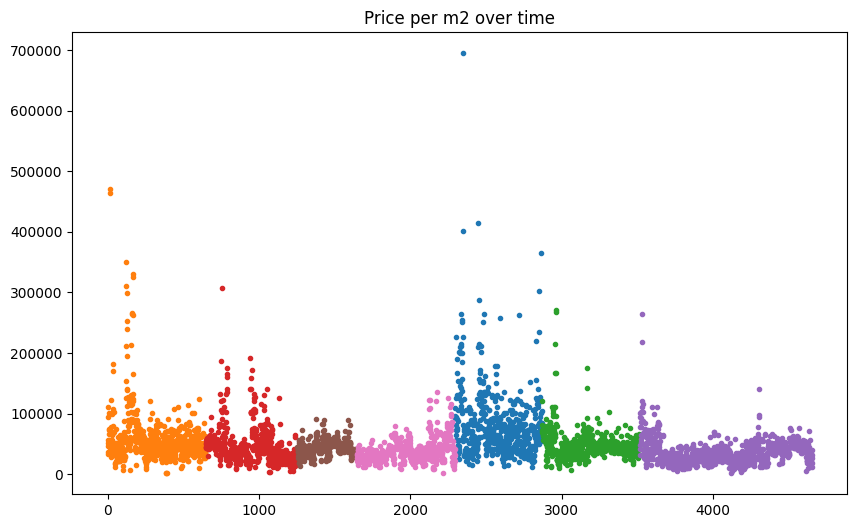

In [166]:
auction_df['Price per m2'].groupby(auction_df['Date']).plot(style='.', figsize=(10,6), title='Price per m2 over time')

Date
2023-06-01    Axes(0.125,0.11;0.775x0.77)
2024-04-01    Axes(0.125,0.11;0.775x0.77)
2024-08-01    Axes(0.125,0.11;0.775x0.77)
2024-11-01    Axes(0.125,0.11;0.775x0.77)
2025-04-01    Axes(0.125,0.11;0.775x0.77)
2025-09-01    Axes(0.125,0.11;0.775x0.77)
2025-10-01    Axes(0.125,0.11;0.775x0.77)
Name: Area size in m2, dtype: object

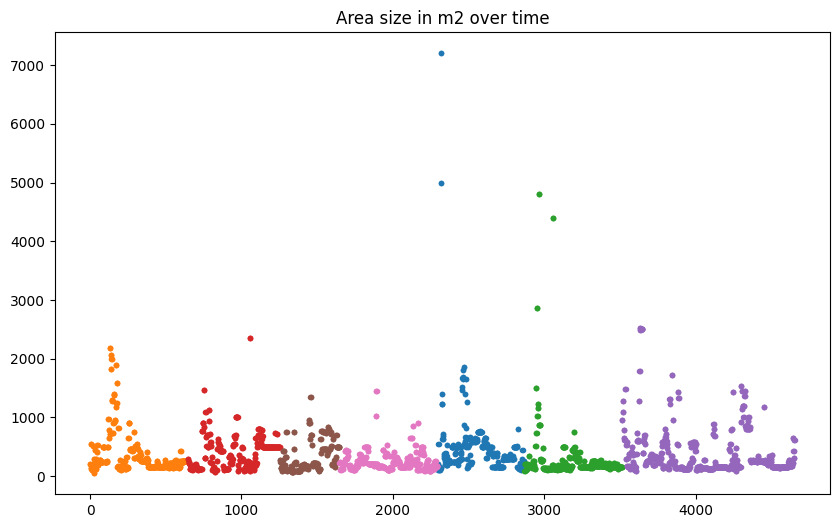

In [167]:
auction_df['Area size in m2'].groupby(auction_df['Date']).plot(style='.', figsize=(10,6), title='Area size in m2 over time')    

In [168]:
auction_df.columns

Index(['Grade', 'Price per m2', 'Advance payment in %', 'Sub-City', 'Woreda',
       'Area size in m2', 'Area code', 'winner', 'Date', 'Remark'],
      dtype='object')

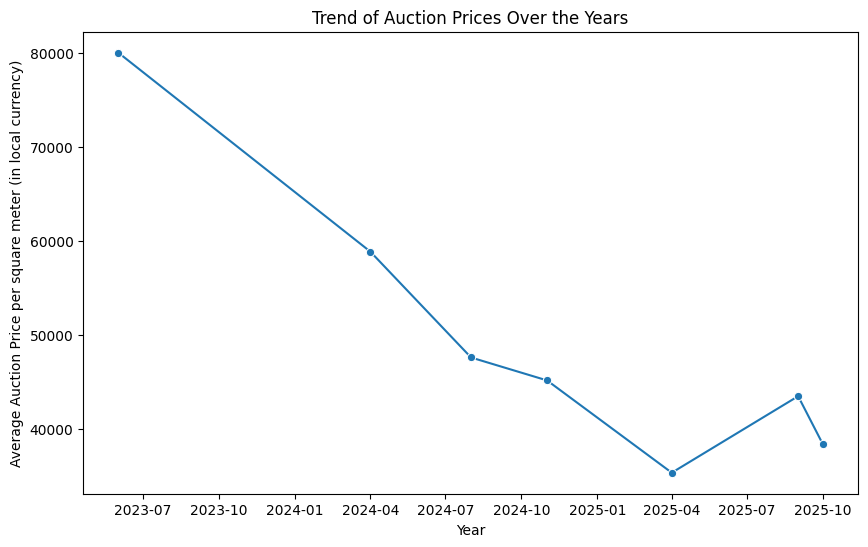

In [169]:
# plot a line chart showing the trend of average auction prices over the years  
plt.figure(figsize=(10, 6))
avg_prices_per_auction = auction_df.groupby('Date')['Price per m2'].mean().reset_index()
sns.lineplot(data=avg_prices_per_auction, x='Date', y='Price per m2', marker='o')
plt.title('Trend of Auction Prices Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Auction Price per square meter (in local currency)') 
plt.show()

C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_13676\1387578428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_prices_by_subcity, x='Sub-City', y='Price per m2', palette='viridis')


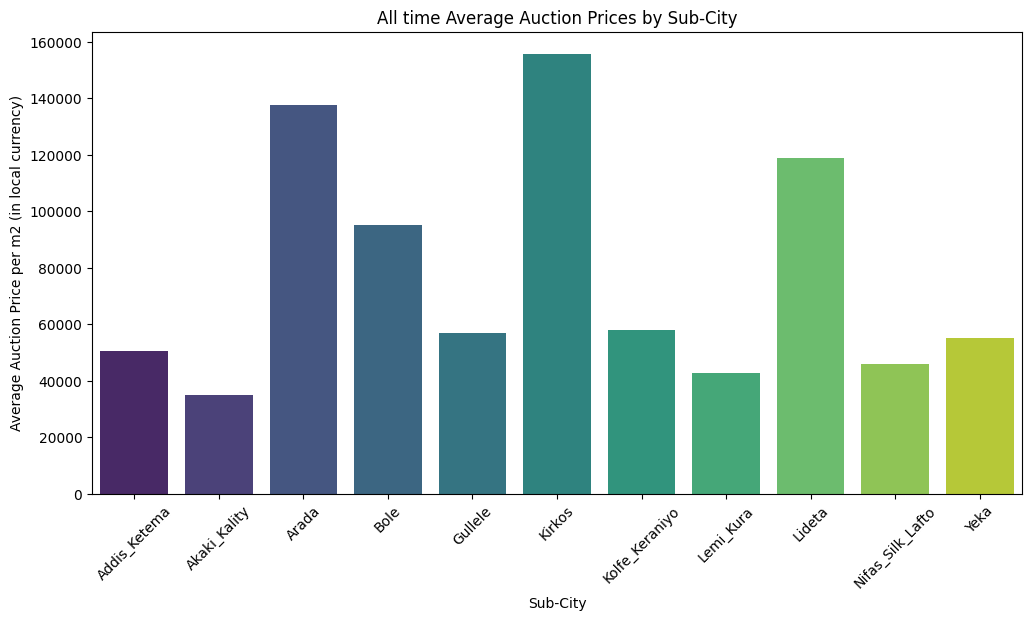

In [170]:
# Plot a bar chart showing average auction prices by Sub-City 
plt.figure(figsize=(12, 6)) 
avg_prices_by_subcity = auction_df.groupby('Sub-City')['Price per m2'].mean().reset_index()
sns.barplot(data=avg_prices_by_subcity, x='Sub-City', y='Price per m2', palette='viridis')
plt.title('All time Average Auction Prices by Sub-City') 
plt.xlabel('Sub-City')
plt.ylabel('Average Auction Price per m2 (in local currency)')
plt.xticks(rotation=45)
plt.show()


C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_13676\3134804540.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Price', bbox_to_anchor=(1.10, 1), loc='upper left')


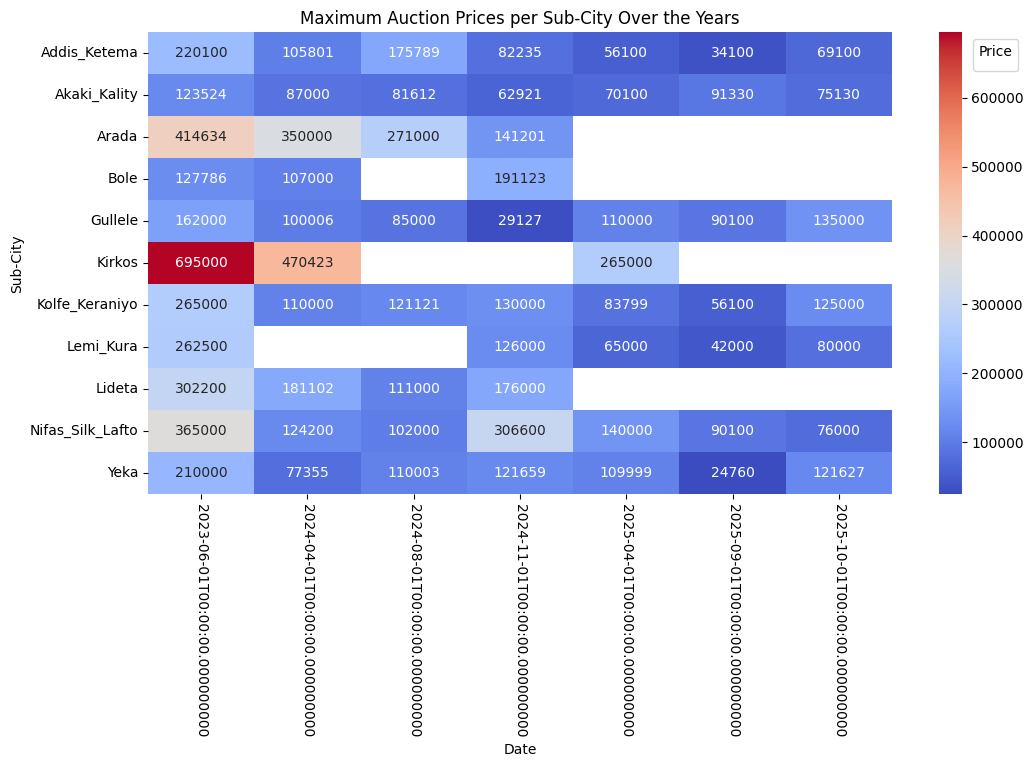

In [171]:
# plot a heatmap showing the maximum auction prices per Sub-City over the years
plt.figure(figsize=(12, 6)) 
max_prices_per_subcity = auction_df.groupby(['Date', 'Sub-City'])['Price per m2'].max().reset_index()
pivot_table = max_prices_per_subcity.pivot(index='Sub-City', columns='Date', values='Price per m2')
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="coolwarm")
plt.title('Maximum Auction Prices per Sub-City Over the Years')
plt.xlabel('Date')
plt.ylabel('Sub-City')
plt.xticks(rotation=-90)
plt.legend(title='Price', bbox_to_anchor=(1.10, 1), loc='upper left')


C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_13676\3825696484.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title =f'Total Area Auctioned to Date: {total_area_auctioned_to_date} m2')


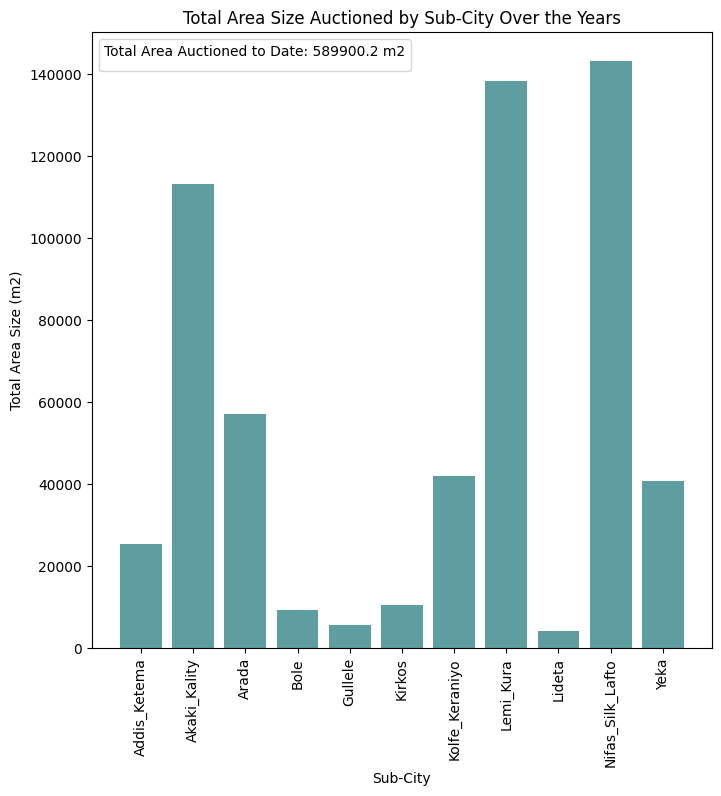

In [172]:
# plot a bar chart showing the total area size auctioned by Sub-City over the years

area_size_by_subcity = auction_df[(auction_df['winner'] == 'Highest Bidder') | (auction_df['winner'] == 'Highest Point')].groupby('Sub-City')['Area size in m2'].sum()
total_area_auctioned_to_date = area_size_by_subcity.sum()
plt.figure(figsize=(8, 8))
plt.bar(area_size_by_subcity.index, area_size_by_subcity, color='cadetblue')
plt.title('Total Area Size Auctioned by Sub-City Over the Years')
plt.xlabel('Sub-City')
plt.ylabel('Total Area Size (m2)')
plt.xticks(rotation=90)
plt.legend(title =f'Total Area Auctioned to Date: {total_area_auctioned_to_date} m2')
plt.show()

In [173]:
area_size_by_subcity

Sub-City
Addis_Ketema         25463.0
Akaki_Kality        113201.0
Arada                57179.0
Bole                  9311.0
Gullele               5675.0
Kirkos               10562.5
Kolfe_Keraniyo       41907.7
Lemi_Kura           138431.0
Lideta                4163.0
Nifas_Silk_Lafto    143177.0
Yeka                 40830.0
Name: Area size in m2, dtype: float64

In [174]:
winners_df = auction_df[(auction_df['winner'] == 'Highest Point') | (auction_df['winner'] == 'Highest Bidder')]
winners_df.head()

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,winner,Date,Remark
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN
3,1,45800.0,100.0,Kolfe_Keraniyo,3,546.0,LDR_KOL_MIX_00013051,Highest Point,2024-04-01,NaN
6,1,110000.0,100.0,Kolfe_Keraniyo,7,134.0,LDR_KOL_MIX_00013089,Highest Bidder,2024-04-01,NaN
9,1,72500.0,100.0,Kolfe_Keraniyo,7,120.0,LDR_KOL_MIX_00013091,Highest Point,2024-04-01,NaN
12,1,51857.0,100.0,Kolfe_Keraniyo,3,106.0,LDR_KOL_MIX_00013093,Highest Bidder,2024-04-01,NaN


In [175]:
total_of_land_sold = (winners_df['Price per m2'] * winners_df['Area size in m2'] * winners_df['Advance payment in %'] / 100).sum()
print(f'Total Amount Earned from Auction Sales is:{total_of_land_sold}')

Total Amount Earned from Auction Sales is:30803970294.051903


C:\Users\Solen Tadesse\AppData\Local\Temp\ipykernel_13676\3069524226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winners_by_subcity.index, y=winners_by_subcity.values, palette='magma')


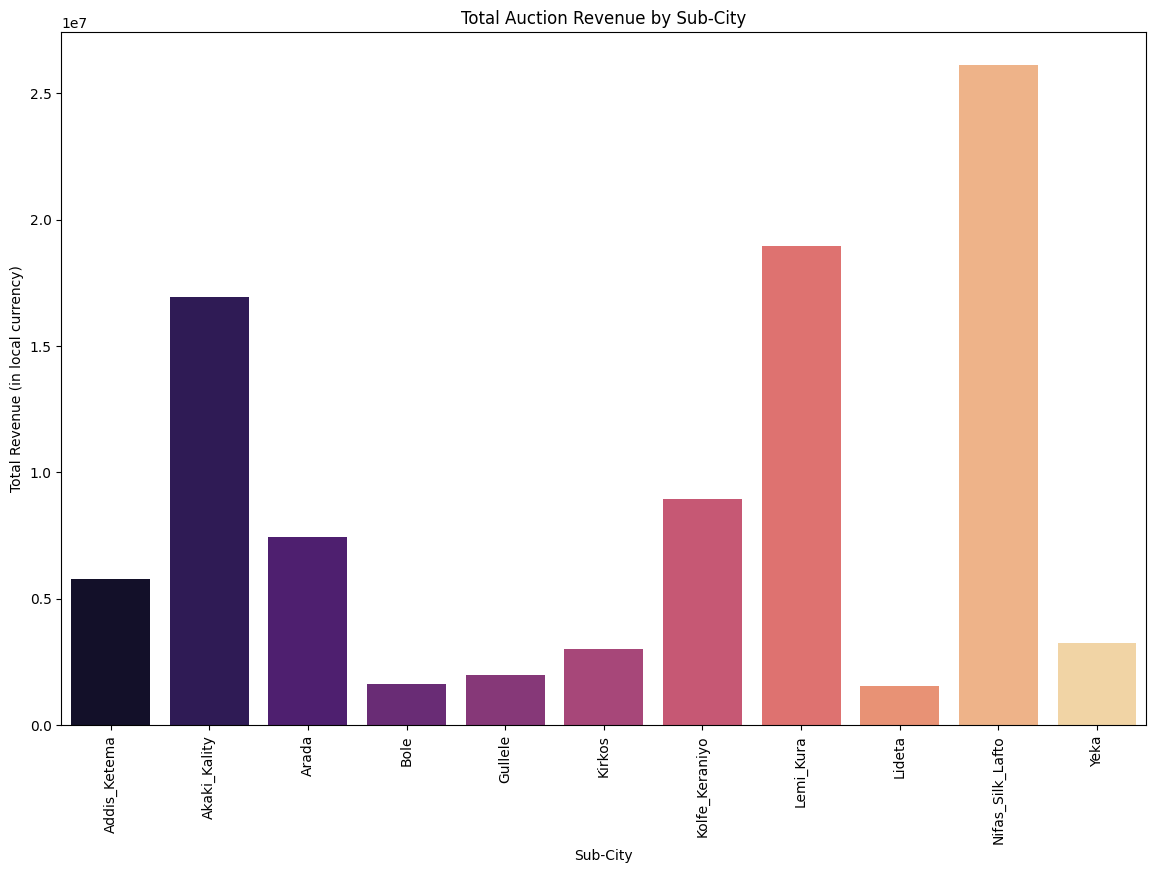

In [176]:
winners_by_subcity = winners_df.groupby('Sub-City')['Price per m2'].sum()
plt.figure(figsize=(14, 9))
sns.barplot(x=winners_by_subcity.index, y=winners_by_subcity.values, palette='magma')
plt.title('Total Auction Revenue by Sub-City')
plt.xlabel('Sub-City')
plt.ylabel('Total Revenue (in local currency)')
plt.xticks(rotation=90)
plt.show()


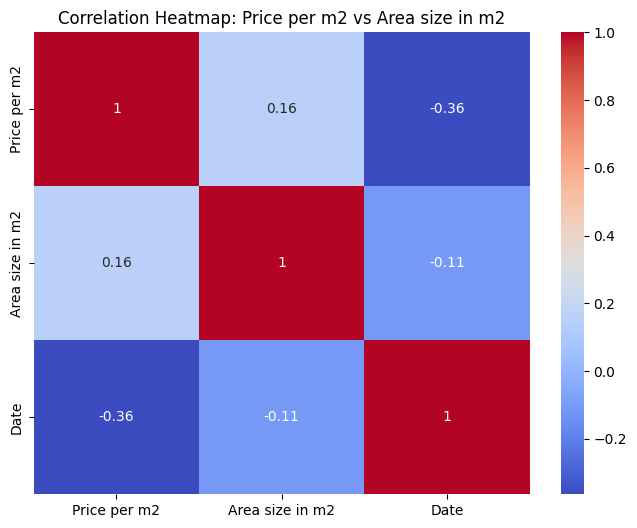

In [177]:
# Correlation Heatmap: See how Area size correlates with Price
plt.figure(figsize=(8, 6))
sns.heatmap(auction_df[['Price per m2', 'Area size in m2', 'Date']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Price per m2 vs Area size in m2')   
plt.show()

array([4., 6.])

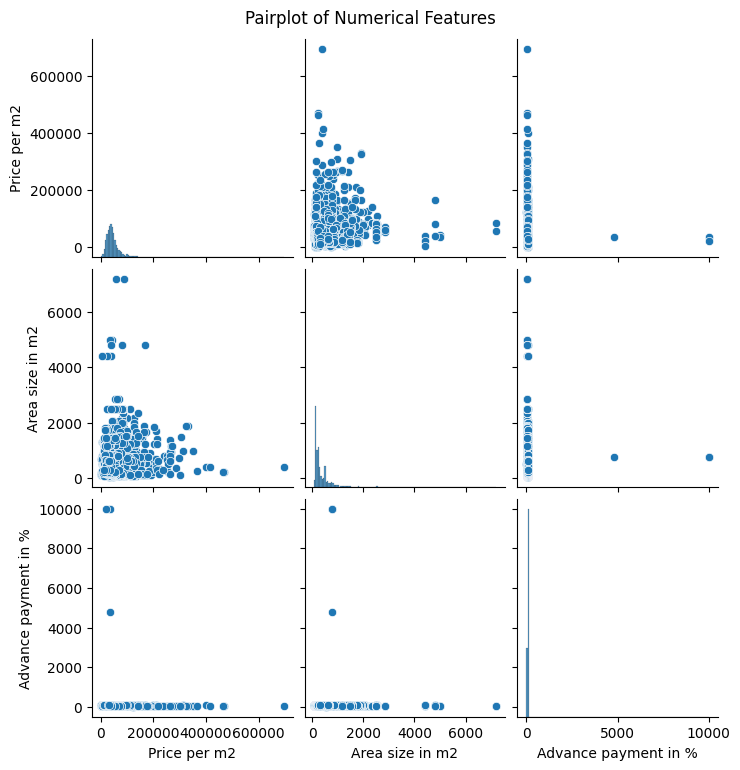

In [178]:
# Show a pairplot to visulaize relationships among the numerical features in the data set
sns.pairplot(auction_df[['Price per m2', 'Area size in m2', 'Advance payment in %']])
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.figaspect(1.5)

In [179]:
#list of all unique woredas
auction_df['Woreda'].unique()

array([ 3,  7,  2, 10, 12,  4,  6,  1,  5, 14, 13,  8,  9, 11, 15])

In [180]:
#count each unique woredas
auction_df['Woreda'].value_counts()

Woreda
1     1109
4      615
3      506
15     474
13     462
14     430
5      268
8      201
7      138
2      115
12     112
9       91
10      69
6       44
11      20
Name: count, dtype: int64

# Feature Engineering
 ### Add a new column with a unique subcity + Woreda
 ### Calculate days_since_start as the no. of days elapsed since first auction

In [181]:
#Create a unique column by combining 'Sub-City' and 'Woreda' columns
auction_df['Sub_City_Woreda'] = auction_df['Sub-City'] + '_' + auction_df['Woreda'].astype(str)

In [182]:
#See if changes are reflected in the dataset
auction_df.head(2)

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,winner,Date,Remark,Sub_City_Woreda
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN,Kolfe_Keraniyo_3
1,2,36100.0,100.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN,Kolfe_Keraniyo_3


In [183]:
# Calculate the number of days since the start of the auction for each entry and add it as a new column 'days_since_start'
auction_df['days_since_start'] = auction_df['Date'] - auction_df['Date'].min()

In [184]:
auction_df.head(3)

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,winner,Date,Remark,Sub_City_Woreda,days_since_start
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN,Kolfe_Keraniyo_3,305 days
1,2,36100.0,100.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN,Kolfe_Keraniyo_3,305 days
2,3,56545.0,61.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN,Kolfe_Keraniyo_3,305 days


In [185]:
auction_df.tail(3)

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,winner,Date,Remark,Sub_City_Woreda,days_since_start
4651,1,40200.00,60.0,Nifas_Silk_Lafto,14,613.0,LDR_NIF_MIX_00014500,Highest Bidder,2025-04-01,NaN,Nifas_Silk_Lafto_14,670 days
4652,2,26101.14,100.0,Nifas_Silk_Lafto,14,613.0,LDR_NIF_MIX_00014500,NaN,2025-04-01,NaN,Nifas_Silk_Lafto_14,670 days
4653,3,31000.00,80.0,Nifas_Silk_Lafto,14,613.0,LDR_NIF_MIX_00014500,NaN,2025-04-01,NaN,Nifas_Silk_Lafto_14,670 days


In [186]:
unique_dates = auction_df['Date'].unique()
unique_dates

<DatetimeArray>
['2024-04-01 00:00:00', '2024-11-01 00:00:00', '2025-09-01 00:00:00',
 '2025-10-01 00:00:00', '2023-06-01 00:00:00', '2024-08-01 00:00:00',
 '2025-04-01 00:00:00']
Length: 7, dtype: datetime64[ns]

In [187]:
all_dates = pd.DataFrame(unique_dates, columns=['Dates'])
sorted_dates = all_dates.sort_values(by='Dates')
sorted_dates


,Dates
4,2023-06-01
0,2024-04-01
5,2024-08-01
1,2024-11-01
6,2025-04-01
2,2025-09-01
3,2025-10-01


In [188]:
months = all_dates['Dates'].dt.month
months

0     4
1    11
2     9
3    10
4     6
5     8
6     4
Name: Dates, dtype: int32

In [189]:
auction_df.head(2)

,Grade,Price per m2,Advance payment in %,Sub-City,Woreda,Area size in m2,Area code,winner,Date,Remark,Sub_City_Woreda,days_since_start
0,1,93460.0,40.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,Highest Bidder,2024-04-01,NaN,Kolfe_Keraniyo_3,305 days
1,2,36100.0,100.0,Kolfe_Keraniyo,3,214.0,LDR_KOL_MIX_00013050,NaN,2024-04-01,NaN,Kolfe_Keraniyo_3,305 days


In [194]:
usd_rate = pd.read_excel(r'C:\Users\Solen Tadesse\ALX_ML\PORTFOLIO\USD to ETB Exchange Rates and Reform.xlsx')
usd_rate

,Date_YMD,Rate_ETB,Context
0,2023-06-01,54.42,Pre-reform stability
1,2024-04-01,56.68,Crawling peg era
2,2024-08-01,105.08,Post-July Reform (Float)
3,2024-11-01,120.35,Market adjustment period
4,2025-04-01,128.90,Steady depreciation
5,2025-09-01,138.45,Projected market rate
6,2025-10-01,142.85,Volatility increase
7,2025-12-01,149.20,End-of-year peak
8,2026-01-01,152.10,New year threshold
9,2026-02-01,154.65,Current 2026 trend


In [195]:
pd.to_datetime(usd_rate['Date_YMD'], format='%Y-%m-%d')
usd_rate['Rate_ETB'].astype(float)

0     54.42
1     56.68
2    105.08
3    120.35
4    128.90
5    138.45
6    142.85
7    149.20
8    152.10
9    154.65
Name: Rate_ETB, dtype: float64

In [196]:
usd_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date_YMD  10 non-null     datetime64[ns]
 1   Rate_ETB  10 non-null     float64       
 2   Context   10 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 372.0+ bytes


In [197]:
if auction_df['Date'] == usd_rate['Date_YMD']:
    auction_df['USD_rate'] = usd_rate['Rate_ETB'] 

ValueError: Can only compare identically-labeled Series objects

In [198]:
auction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654 entries, 0 to 4653
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   Grade                 4654 non-null   int64          
 1   Price per m2          4654 non-null   float64        
 2   Advance payment in %  4654 non-null   float64        
 3   Sub-City              4654 non-null   object         
 4   Woreda                4654 non-null   int64          
 5   Area size in m2       4654 non-null   float64        
 6   Area code             4654 non-null   object         
 7   winner                1647 non-null   object         
 8   Date                  4654 non-null   datetime64[ns] 
 9   Remark                90 non-null     object         
 10  Sub_City_Woreda       4654 non-null   object         
 11  days_since_start      4654 non-null   timedelta64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(5), timedel